<a href="https://colab.research.google.com/github/miaflynn/CYPLAN255-Final-Project/blob/main/01a-processed-data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [134]:
import pandas as pd
import geopandas as gpd
import numpy as np

#added more that we use in lab
import os
%matplotlib inline
import matplotlib.pyplot as plt
from shapely.geometry import LineString


In [135]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [136]:
gdf = pd.read_csv("/content/drive/MyDrive/C255_final_project/raw/rbl_sf.csv")

In [137]:
###renaming columns

new_names = gdf.columns.str.strip().str.replace(' #', '_num').str.replace(' - ', '_').str.replace(' ', '_').str.lower()
gdf.columns = new_names
gdf.columns

Index(['uniqueid', 'business_account_number', 'location_id', 'ownership_name',
       'dba_name', 'street_address', 'city', 'state', 'source_zipcode',
       'business_start_date', 'business_end_date', 'location_start_date',
       'location_end_date', 'administratively_closed', 'mail_address',
       'mail_city', 'mail_state', 'mail_zipcode', 'naics_code',
       'naics_code_description', 'naics_code_descriptions_list', 'lic_code',
       'lic_code_description', 'lic_code_descriptions_list', 'parking_tax',
       'transient_occupancy_tax', 'business_location', 'business_corridor',
       'neighborhoods_analysis_boundaries', 'supervisor_district',
       'community_benefit_district', 'data_as_of', 'data_loaded_at'],
      dtype='object')

In [138]:
num_duplicates = gdf.duplicated().sum()
pct_duplicates = (num_duplicates / len(gdf)) * 100
print(num_duplicates, pct_duplicates)

##no duplicates in dataset

0 0.0


In [139]:
##fixing geometries of business location column

#I'm adjusting this code a little bc it's not running for me

from shapely import wkt

# Making copy and removing rows without location data bc it won't run otherwise
gdf = gdf[gdf["business_location"].notna()].copy()

# Converting string to geometry
gdf["geometry"] = gdf["business_location"].apply(wkt.loads)

#Right now it's a df so I'm making it a gdf
gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs="EPSG:4326")


In [140]:
##setting crs and correcting datetimes

gdf['business_start_date'] = pd.to_datetime(gdf['business_start_date'], format = '%m/%d/%Y', errors = 'coerce')
gdf['business_end_date'] = pd.to_datetime(gdf['business_end_date'], format = '%m/%d/%Y', errors = 'coerce')
gdf['location_start_date'] = pd.to_datetime(gdf['location_start_date'], format = '%m/%d/%Y', errors = 'coerce')
gdf['location_end_date'] = pd.to_datetime(gdf['location_end_date'], format = '%m/%d/%Y', errors = 'coerce')
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 344373 entries, 0 to 356174
Data columns (total 34 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   uniqueid                           344373 non-null  object        
 1   business_account_number            344373 non-null  int64         
 2   location_id                        344373 non-null  object        
 3   ownership_name                     344372 non-null  object        
 4   dba_name                           344051 non-null  object        
 5   street_address                     344373 non-null  object        
 6   city                               344288 non-null  object        
 7   state                              344112 non-null  object        
 8   source_zipcode                     344114 non-null  float64       
 9   business_start_date                344373 non-null  datetime64[ns]
 10  business_end_date

In [141]:
missing = gdf.isna().sum()
display(missing.sort_values(ascending=False))

,0
lic_code_descriptions_list,331288
lic_code_description,331288
lic_code,331228
business_corridor,311833
administratively_closed,303075
community_benefit_district,269852
mail_state,185972
mail_zipcode,185940
mail_city,185922
mail_address,185912


In [142]:
##admin closed to boolean
admin_closed_mask = gdf['administratively_closed'] == '***Administratively Closed'
gdf['administratively_closed_bool'] = admin_closed_mask

13145
166190


,naics_code,naics_code_description,lic_code,lic_code_description
268599,NaN,NaN,H70,SOLO PRACTITIONER MASSAGE ESTABLISHMENT
103657,4400-4599,Retail Trade,D08 D14 H07 H31 POS01 WM08,Multiple
120908,5400-5499,"Professional, Scientific, and Technical Services",NaN,NaN
56905,4200-4299 4400-4599,Multiple,H07 WM18,Multiple
164297,7100-7199,"Arts, Entertainment, and Recreation",NaN,NaN
40254,6100-6299,Private Education and Health Services,NaN,NaN
57797,7220-7229,Food Services,NaN,NaN
214631,5300-5399,Real Estate and Rental and Leasing Services,NaN,NaN
326576,2300-2399,Construction,NaN,NaN
331340,5100-5199,Information,NaN,NaN


<Axes: >

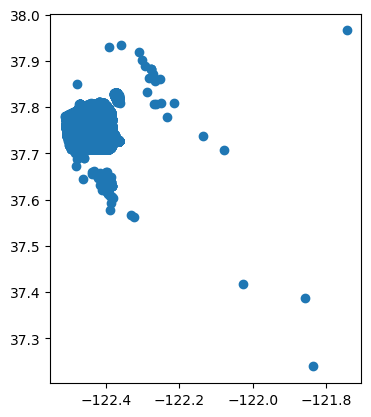

In [143]:
## filtering for having a code

lic_mask = gdf['lic_code'].notna()
print(lic_mask.sum())
naics_mask = gdf['naics_code'].notna()
print(naics_mask.sum())
gdf_hascode = gdf[lic_mask | naics_mask]

code_cols = [
    'naics_code', 'naics_code_description', 'lic_code','lic_code_description'
]

display(gdf_hascode[code_cols].sample(20))

##filtered only by businesses with code, but still having business locations all across the United States?
# I think a lot of the addresses are elsewhere bc the business headquarters location may not be in SF - if you look at the table it shows this - Abigail

# Commenting this out bc I'm going to also filter the boundaries of Sf - Abigail
# gdf_hascode_sf = gdf_hascode[gdf_hascode['city'] == 'San Francisco']

# Bounds from here: https://wiki.openstreetmap.org/wiki/San_Francisco,_California
sanfran_bounds = {
    "minx": -123,
    "maxx": -121.5,
    "miny": 37,
    "maxy": 38
}

gdf_hascode_sf = gdf_hascode[
    (gdf_hascode['city'] == 'San Francisco') &
    (gdf_hascode.geometry.x >= sanfran_bounds["minx"]) &
    (gdf_hascode.geometry.x <= sanfran_bounds["maxx"]) &
    (gdf_hascode.geometry.y >= sanfran_bounds["miny"]) &
    (gdf_hascode.geometry.y <= sanfran_bounds["maxy"])
]

gdf_hascode_sf.plot()

In [144]:
# adding another plot and importing a shpfile of SF so we can see where the points are in SF

import matplotlib.pyplot as plt

# Importing SF geometry
# URL for 2025 TIGER/Line Place boundaries - info here on
## how to use: https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
url = "https://www2.census.gov/geo/tiger/TIGER2025/PLACE/tl_2025_06_place.zip"

places = gpd.read_file(url)

# Filtered to SF
sf_poly = places[
    (places["NAME"] == "San Francisco") &
    (places["STATEFP"] == "06")   # 06 = California
]


# eproject to same as our gdf
sf_poly = sf_poly.to_crs(epsg=4326)

# keeping just the points in sf bc there are a lot outside
gdf_sf = gpd.sjoin(gdf_hascode_sf, sf_poly, predicate="within") ##joined with gdf_hascode_sf instead, so we only have coded businesses -Sean


In [145]:
##quickly looking at gdf_sf codes

gdf_sf.columns

cols_to_keep = [
    'uniqueid', 'business_account_number', 'location_id', 'ownership_name',
    'dba_name', 'business_start_date', 'business_end_date', 'location_start_date',
    'location_end_date', 'naics_code','naics_code_description', 'lic_code',
    'lic_code_description', 'business_corridor','neighborhoods_analysis_boundaries',
    'geometry', 'administratively_closed_bool'
]

gdf_sf = gdf_sf[cols_to_keep].copy()
gdf_sf

,uniqueid,business_account_number,location_id,ownership_name,dba_name,business_start_date,business_end_date,location_start_date,location_end_date,naics_code,naics_code_description,lic_code,lic_code_description,business_corridor,neighborhoods_analysis_boundaries,geometry,administratively_closed_bool
926,0183810-01-001-0183810,183810,0183810-01-001,Callan Robert & Callan Willia,179 Alhambra St Apartments,1988-04-01,NaT,1988-04-01,2015-06-16,5300-5399,Real Estate and Rental and Leasing Services,NaN,NaN,NaN,Marina,POINT (-122.43917 37.80152),False
928,0339974-46-001-0339974,339974,0339974-46-001,Tower Valet Parking Inc,Tower Valet Parking Inc,2000-10-01,NaT,2013-06-01,NaT,8100-8139,Certain Services,NaN,NaN,NaN,Financial District/South Beach,POINT (-122.39223 37.79035),False
930,1410027-02-261-1165963,1165963,1410027-02-261,"Agua Frisco, Inc",Agua Frisco,2025-01-15,NaT,2026-02-01,NaT,7220-7229,Food Services,NaN,NaN,NaN,Treasure Island,POINT (-122.37379 37.82587),False
931,1239658-12-191-1109070,1109070,1239658-12-191,"Emptor.Ai, Inc.",Openwrench,2019-12-01,2023-06-30,2019-12-01,2023-06-30,5100-5199,Information,NaN,NaN,NaN,West of Twin Peaks,POINT (-122.43779 37.73136),True
932,1055584-02-161-1027028,1027028,1055584-02-161,"Propel Venture Partners Mgmt. Co., LLC","Propel Venture Partners Mgmt. Co., LLC",2016-02-01,2020-09-30,2016-02-01,2020-09-30,5210-5239,Financial Services,NaN,NaN,NaN,Financial District/South Beach,POINT (-122.40044 37.7888),False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
356165,1022437-03-151-1010847,1010847,1022437-03-151,Xenoform Labs LLC,Xenoform Labs LLC,2015-02-24,2026-02-24,2015-02-24,2026-02-24,7100-7199 7210-7219,Multiple,NaN,NaN,NaN,Mission,POINT (-122.42081 37.75703),False
356167,0123862-02-001-0123862,123862,0123862-02-001,Cadgene Allan H,400 To 410 Cole St Apts,1978-03-17,NaT,1994-02-01,NaT,5300-5399,Real Estate and Rental and Leasing Services,NaN,NaN,NaN,Haight Ashbury,POINT (-122.4504 37.77125),False
356171,1372338-10-241-1162933,1162933,1372338-10-241,Mitzy Azucena Lopez,M&G Auto Collision,2024-10-10,NaT,2024-10-10,2024-12-06,8100-8139,Certain Services,NaN,NaN,NaN,Mission,POINT (-122.41849 37.76424),False
356172,1271479-03-211-1010335,1010335,1271479-03-211,Quadri Foglio LLC,Mensho Geary LLC,2015-03-01,NaT,2015-03-01,NaT,7220-7229,Food Services,H24,"RESTAURANT - UNDER 1,000 SQFT",NaN,Tenderloin,POINT (-122.41441 37.78687),False


In [146]:
#filter for location end dates 2016 onwards and businesses without end dates (still open)

filtered_gdf = gdf_sf[
    (gdf_sf['location_end_date'].dt.year >= 2016) | (gdf_sf['location_end_date'].isna())
]

###Creating opening and closing gdfs

In [147]:

# Making a year column

# converting the start and end dates to years using datetime
filtered_gdf['location_start_date'] = pd.to_datetime(filtered_gdf['location_start_date'], errors='coerce')
filtered_gdf['location_end_date'] = pd.to_datetime(filtered_gdf['location_end_date'], errors='coerce')

# making df for business openings
openings = filtered_gdf.copy()
openings["year"] = openings["location_start_date"].dt.year
openings["status"] = "opened"

# making df for business closings
closings = filtered_gdf[filtered_gdf["location_end_date"].notna()].copy()
closings["year"] = closings["location_end_date"].dt.year
closings["status"] = "closed"

gdf_open_close = pd.concat([openings, closings])
gdf_open_close.count()

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,0
uniqueid,194649
business_account_number,194649
location_id,194649
ownership_name,194649
dba_name,194464
business_start_date,194649
business_end_date,82106
location_start_date,194649
location_end_date,123208
naics_code,191147


In [148]:
#adding status to base list
filtered_gdf['status'] = 'opened'
filtered_gdf.loc[filtered_gdf['location_end_date'].isna(), 'status'] = 'closed'

filtered_gdf['year_open'] = filtered_gdf['location_start_date'].dt.year
filtered_gdf['year_closed'] = filtered_gdf['location_end_date'].dt.year

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

###Plotting openings and closings by year

In [149]:
# getting lat and lon instead of geometry for plotly to work

filtered_gdf["lon"] = filtered_gdf.geometry.x
filtered_gdf["lat"] = filtered_gdf.geometry.y


filtered_gdf = filtered_gdf.sort_values(by='year_open')

filtered_gdf.columns

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Index(['uniqueid', 'business_account_number', 'location_id', 'ownership_name',
       'dba_name', 'business_start_date', 'business_end_date',
       'location_start_date', 'location_end_date', 'naics_code',
       'naics_code_description', 'lic_code', 'lic_code_description',
       'business_corridor', 'neighborhoods_analysis_boundaries', 'geometry',
       'administratively_closed_bool', 'status', 'year_open', 'year_closed',
       'lon', 'lat'],
      dtype='object')

In [150]:
#filtering for naics categories of interest (still need to figure out how to include rows that contain these codes in the multiple column ) -Mia

target_codes = '4400-4599|7220-7229|7100-7199'

rde_gdf = filtered_gdf[filtered_gdf['naics_code'].str.contains(target_codes, na=False)]

rde_open_close = gdf_open_close[gdf_open_close['naics_code'].str.contains(target_codes, na=False)]


##Exporting



In [151]:
#exporting all to geojson

base = '/content/drive/MyDrive/C255_final_project/cleaned/'

filtered_gdf.to_file(base + 'biz_all_startdate.geojson', driver='GeoJSON')
gdf_open_close.to_file(base + 'open_close_all_startdate.geojson', driver='GeoJSON')
rde_gdf.to_file(base + 'rde_biz_all_startdate.geojson', driver='GeoJSON')
rde_open_close.to_file(base + 'rde_open_close_all_startdate.geojson', driver='GeoJSON')

#Sean thoughts

Trying to think through this, and I think there's a few different options for how we could consider the data:
- We could look at net change in businesses in a given census tract from the year prior
  - i.e 'The Bayview neighborhood has seen a decrease in 500 businesses since 2019, while the Marina has seen an increase in 150 business locations'
  - this would be cool because we could see where economic development has shifted to
- net change in businesses from an established pre-pandemic baseline
  - essentially compounding the net change year after year from 2019
- We could look at net change per capita (or per land area)
  - I'm less certain about what we gain from this given that corridors serve the broader city and neighborhood too
    - maybe we could organize these at broader neighborhood level rather than tract level to address this problem?
    - or (more complicated), could do net change per capita based on the population of the tract and all tracts within a certain range away
- Business survival rate
  - How many businesses that were open pre-pandemic survived the pandemic?
    - we would need to keep the entire dataset and sort by location openings before march 2020 and either a nonexistent closing date or closing date after March 2020
    - This would help us avoid discounting tracts that saw less of a business fallout in general -- presumably there are some tracts that have a high business survival rate and low growth since then -- and other tracts that had many businesses close and many reopen -- without this, both instances would show little net change except in the year-to-year comparisons
- Could combine point 1 and 4 and create a recovery index

~

Separate question: Does the dataset report temporary closures?
- Are there instances where both the name of the business *and* the location is the same? If so, does one of them have a closing date?
  - also does this matter lol
